#### Problem Statement

**The laptop market on Flipkart offers a wide variety of products from different brands, specifications, and price ranges. Customers often find it difficult to compare laptops and identify the factors that significantly influence their prices.**

**The objective of this project is to analyze laptop listings available on Flipkart and understand the relationship between laptop prices and their specifications. The analysis aims to identify pricing trends, compare brands, and determine which features contribute most to the cost of a laptop.**

`Target Feature`

1. Price (Laptop Price)

- This is the main variable to be analyzed and potentially predicted using other laptop specifications.

`Relevant Features`

1. Brand (HP, Dell, Lenovo, ASUS, Acer, Apple, etc.)
2. Processor Type (Intel i3, i5, i7, AMD Ryzen, etc.)
3. RAM Size
4. Storage Type (SSD/HDD)
5. Storage Capacity
6. Screen Size
7. Operating System
8. Customer Ratings
9. Number of Ratings
10. Number of Reviews
11. Discount Percentage

In [2]:
# importing all necessary libraries
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re

In [4]:
headers= {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,/;q=0.8",
    "Referer": "https://www.google.com/"
}

In [151]:
prices = []
laptop_brands = []
laptop_names = []
processor_types = []
ram_capacities = []
storage_capacities = []
storage_types = []
screen_sizes = []
operating_systems = []
no_of_ratings = []
customer_ratings = []
no_of_reviews = []
discount_percentage = []

for i in range(1,22):
    urls = f"https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={i}"
    page = requests.get(urls,headers=headers)
    soup = BeautifulSoup(page.text)
        
    products = soup.find_all("div", class_="nZIRY7")

    for product in products:
        price_tag = product.find("div", class_="hZ3P6w DeU9vF")

        if price_tag:
            prices.append(price_tag.text)
        else:
            prices.append("")

        name_tag = product.find("div", class_="RG5Slk")

        if name_tag:
            laptop_names.append(name_tag.text.split(" - (")[0])
            laptop_brands.append(name_tag.text.split()[0])
        else:
            laptop_names.append("")
            laptop_brands.append("")
        
        features = product.find_all("li", class_="DTBslk")

        processor = ""
        ram = ""
        os = ""
        storage_capacity = ""
        storage_type = ""
        screen_size = ""

        rating = ""
        ratings_count = ""
        reviews_count = ""
        discount = ""
    
        for f in features:
            text = f.text
            
            if "Processor" in text:
                processor = text.split("(")[0].strip()
    
            elif "RAM" in text:
                m = re.search(r"(\d+\s*GB)", text)
                if m:
                    ram = m.group(1)
    
            elif "Operating System" in text:
                os = text.replace("Operating System", "").strip()
    
            elif "SSD" in text or "HDD" in text:
                m = re.search(r"(\d+\s*(GB|TB))\s*(SSD|HDD)", text)
                if m:
                    storage_capacity = m.group(1)
                    storage_type = m.group(3)
    
            elif "Display" in text:
                m = re.search(r"\((\d+(?:\.\d+)?)\s*inch\)", text, re.I)

                if m:
                    screen_size = m.group(1)
    
        processor_types.append(processor)
        ram_capacities.append(ram)
        operating_systems.append(os)
        storage_capacities.append(storage_capacity)
        storage_types.append(storage_type)
        screen_sizes.append(screen_size)

        # Rating
        rating_tag = product.find("div", class_="MKiFS6")
        if rating_tag:
            rating = rating_tag.get_text(strip=True)
        
        # Ratings & Reviews
        review_tag = product.find("span", class_="PvbNMB")
        if review_tag:
            text = review_tag.get_text(" ", strip=True)
        
            ratings_match = re.search(r'([\d,]+)\s+Ratings?', text)
            reviews_match = re.search(r'([\d,]+)\s+Reviews?', text)
        
            if ratings_match:
                ratings_count = ratings_match.group(1).replace(",", "")
        
            if reviews_match:
                reviews_count = reviews_match.group(1).replace(",", "")
                
        customer_ratings.append(rating)
        no_of_ratings.append(ratings_count)
        no_of_reviews.append(reviews_count)


        discount_tag = product.find("div", class_="HQe8jr")
        
        if discount_tag:
            match = re.search(r'(\d+)%', discount_tag.text)
            if match:
                discount = match.group(1)
        
        discount_percentage.append(discount)

In [162]:
# Converting the scraped data to DataFrame 
laptop_data_all = {"Prices":prices,"Brands":laptop_brands,"Model":laptop_names,"Processor Type":processor_types,"RAM":ram_capacities,"Operating System":operating_systems,"Storage Capacity":storage_capacities,"Storage Type":storage_types, "Screen Size":screen_sizes, "Customer Ratings":customer_ratings, "Ratings Count": no_of_ratings,"Reviews Count": no_of_reviews,"Discount Percentage": discount_percentage}
data = pd.DataFrame(laptop_data_all)

In [163]:
# Exporting the data frame into .csv format 
data.to_csv("multipage_laptops_data.csv")

In [89]:
# Reading CSV File
df = pd.read_csv(r"multipage_laptops_data.csv")

In [90]:
df.head()

,Unnamed: 0,Prices,Brands,Model,Processor Type,RAM,Operating System,Storage Capacity,Storage Type,Screen Size,Customer Ratings,Ratings Count,Reviews Count,Discount Percentage
0,0,"₹16,990",ASUS,ASUS Chromebook CX14 Intel Celeron Dual Core N50,Intel Celeron Dual Core Processor,4 GB,Chrome,NaN,NaN,14.0,3.8,259.0,29.0,26.0
1,1,"₹17,990",Lenovo,Lenovo Chromebook 11IJL9 Intel Celeron Dual Co...,Intel Celeron Dual Core Processor,4 GB,Chrome,NaN,NaN,11.6,4.0,89.0,9.0,42.0
2,2,"₹46,990",ASUS,ASUS ExpertBook P1 (i3 14th Gen) with 1 Yr ADP...,Intel Core 3 Processor,8 GB,64 bit Windows 11 Home,512 GB,SSD,14.0,4.5,68.0,6.0,32.0
3,3,"₹38,990",Acer,Acer Aspire 3 AMD Ryzen 3 Quad Core 7330U,AMD Ryzen 3 Quad Core Processor,8 GB,Windows 11,256 GB,SSD,15.6,4.2,900.0,102.0,45.0
4,4,"₹66,990",ASUS,ASUS Vivobook 14 (2025) with Office 2024 + M36...,Intel Core Ultra 5 Processor,16 GB,Windows 11 Home,512 GB,SSD,14.0,4.4,39.0,6.0,18.0


In [91]:
# list features(Columns) of dataframe
df.columns

Index(['Unnamed: 0', 'Prices', 'Brands', 'Model', 'Processor Type', 'RAM',
       'Operating System', 'Storage Capacity', 'Storage Type', 'Screen Size',
       'Customer Ratings', 'Ratings Count', 'Reviews Count',
       'Discount Percentage'],
      dtype='object')

In [92]:
# list observations(rows) of dataframe
df.head(10)

,Unnamed: 0,Prices,Brands,Model,Processor Type,RAM,Operating System,Storage Capacity,Storage Type,Screen Size,Customer Ratings,Ratings Count,Reviews Count,Discount Percentage
0,0,"₹16,990",ASUS,ASUS Chromebook CX14 Intel Celeron Dual Core N50,Intel Celeron Dual Core Processor,4 GB,Chrome,NaN,NaN,14.0,3.8,259.0,29.0,26.0
1,1,"₹17,990",Lenovo,Lenovo Chromebook 11IJL9 Intel Celeron Dual Co...,Intel Celeron Dual Core Processor,4 GB,Chrome,NaN,NaN,11.6,4.0,89.0,9.0,42.0
2,2,"₹46,990",ASUS,ASUS ExpertBook P1 (i3 14th Gen) with 1 Yr ADP...,Intel Core 3 Processor,8 GB,64 bit Windows 11 Home,512 GB,SSD,14.0,4.5,68.0,6.0,32.0
3,3,"₹38,990",Acer,Acer Aspire 3 AMD Ryzen 3 Quad Core 7330U,AMD Ryzen 3 Quad Core Processor,8 GB,Windows 11,256 GB,SSD,15.6,4.2,900.0,102.0,45.0
4,4,"₹66,990",ASUS,ASUS Vivobook 14 (2025) with Office 2024 + M36...,Intel Core Ultra 5 Processor,16 GB,Windows 11 Home,512 GB,SSD,14.0,4.4,39.0,6.0,18.0
5,5,"₹20,990",ASUS,ASUS Chromebook CX15 Intel Celeron Dual Core N50,Intel Celeron Dual Core Processor,4 GB,Chrome,NaN,NaN,15.6,4.1,102.0,10.0,22.0
6,6,"₹42,990",ASUS,ASUS Vivobook 15 (2025) with Office 2024 + M36...,Intel Core i3 Processor,8 GB,Windows 11 Home,512 GB,SSD,15.6,4.5,89.0,5.0,15.0
7,7,"₹76,990",ASUS,ASUS Expertbook P3 Metal High-performance proc...,Intel Core i7 Processor,32 GB,Windows 11 Home,1 TB,SSD,14.0,4.4,256.0,33.0,35.0
8,8,"₹15,299",Ultimus,Ultimus Intel Celeron Dual Core,Intel Celeron Dual Core Processor,4 GB,64 bit Windows 11 Home,NaN,NaN,14.1,2.6,10.0,1.0,45.0
9,9,"₹15,500",Jio,Jio MediaTek MT8788,MediaTek MT8788 Processor,4 GB,JioOS,NaN,NaN,11.6,4.3,3.0,0.0,38.0


In [93]:
# Listing data type of each feature
df.dtypes


Unnamed: 0               int64
Prices                  object
Brands                  object
Model                   object
Processor Type          object
RAM                     object
Operating System        object
Storage Capacity        object
Storage Type            object
Screen Size            float64
Customer Ratings       float64
Ratings Count          float64
Reviews Count          float64
Discount Percentage    float64
dtype: object

In [94]:
# Removing the special characters and Converting the data types for Price,RAM, storage capacity
# Price
df['Prices'] = (
    df['Prices']
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(int)
)

# RAM
df['RAM'] = df['RAM'].str.extract(r'(\d+)').astype(int)

# Storage
df['Storage Capacity'] = pd.to_numeric(
    df['Storage Capacity'].str.extract(r'(\d+)')[0],
    errors='coerce'
)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           504 non-null    int64  
 1   Prices               504 non-null    int64  
 2   Brands               504 non-null    object 
 3   Model                504 non-null    object 
 4   Processor Type       504 non-null    object 
 5   RAM                  504 non-null    int64  
 6   Operating System     504 non-null    object 
 7   Storage Capacity     346 non-null    float64
 8   Storage Type         346 non-null    object 
 9   Screen Size          504 non-null    float64
 10  Customer Ratings     481 non-null    float64
 11  Ratings Count        481 non-null    float64
 12  Reviews Count        481 non-null    float64
 13  Discount Percentage  447 non-null    float64
dtypes: float64(6), int64(3), object(5)
memory usage: 55.3+ KB


In [96]:
# Calculate overall missing values count of all columns
df.isnull().sum()

Unnamed: 0               0
Prices                   0
Brands                   0
Model                    0
Processor Type           0
RAM                      0
Operating System         0
Storage Capacity       158
Storage Type           158
Screen Size              0
Customer Ratings        23
Ratings Count           23
Reviews Count           23
Discount Percentage     57
dtype: int64

In [97]:
# Dropping Incorrect Headers
df.drop({"Unnamed: 0"}, axis=1,inplace=True)

#### Identify Missing Values

In [98]:
df.isnull().sum()

Prices                   0
Brands                   0
Model                    0
Processor Type           0
RAM                      0
Operating System         0
Storage Capacity       158
Storage Type           158
Screen Size              0
Customer Ratings        23
Ratings Count           23
Reviews Count           23
Discount Percentage     57
dtype: int64

In [99]:
# Check the percentage of missing values
(df.isnull().sum() / len(df)) * 100

Prices                  0.000000
Brands                  0.000000
Model                   0.000000
Processor Type          0.000000
RAM                     0.000000
Operating System        0.000000
Storage Capacity       31.349206
Storage Type           31.349206
Screen Size             0.000000
Customer Ratings        4.563492
Ratings Count           4.563492
Reviews Count           4.563492
Discount Percentage    11.309524
dtype: float64

#### Treatment of Missing Values

In [100]:
df.fillna({
    'Storage Capacity': df['Storage Capacity'].median(),
    'Storage Type': df['Storage Type'].fillna('Unknown'),
    'Customer Ratings': df['Customer Ratings'].median(),
    'Ratings Count': df['Ratings Count'].median(),
    'Reviews Count': df['Reviews Count'].median(),
    'Discount Percentage': df['Discount Percentage'].median()
}, inplace=True)

In [101]:
# Verifying
df.isnull().sum()

Prices                 0
Brands                 0
Model                  0
Processor Type         0
RAM                    0
Operating System       0
Storage Capacity       0
Storage Type           0
Screen Size            0
Customer Ratings       0
Ratings Count          0
Reviews Count          0
Discount Percentage    0
dtype: int64

#### EDA Report
Missing values were identified using isnull().sum(). Numerical features (Storage Capacity,Customer Ratings, Reviews Count, Ratings Count and Discount Percentage) were imputed using the median. The missing values were handled without dropping records to preserve the dataset size.

In [102]:
# Verify duplicate rows
df.duplicated().sum()

np.int64(241)

In [103]:
# Check exact duplicate count based on Model and Price
df.duplicated(subset=['Model', 'Prices']).sum()

np.int64(247)

In [104]:
# Dropping duplicates
print("Before:", len(df))
df = df.drop_duplicates(subset=['Model', 'Prices'])
print("After :", len(df))

Before: 504
After : 257


#### Duplicate Records Analysis
- During data quality assessment, 241 duplicate records were identified using the duplicated() function.
- After investigation, it was observed that Flipkart repeats the same laptop listings across multiple search result pages (especially popular and sponsored products).
- Since these were website-generated duplicate listings and not scraping errors, duplicate records were removed using drop_duplicates() to avoid biased analysis.
- This ensured that each unique laptop model was represented only once in the final dataset, resulting in more accurate EDA and business insights.

#### Identifying and treating the Outliers

For Flipkart Laptop Price Analysis, outlier treatment should be done mainly on numerical columns such as:

- Prices
- RAM
- Storage Capacity
- Screen Size
- Customer Ratings
- Ratings Count
- Reviews Count
- Discount Percentage

1. Identify Outliers

Using Boxplots

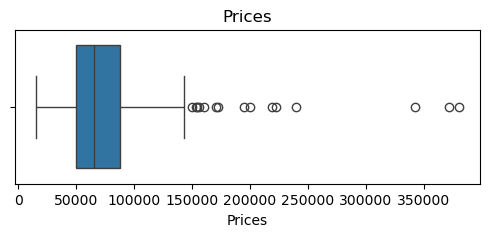

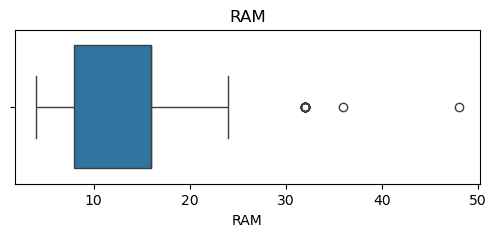

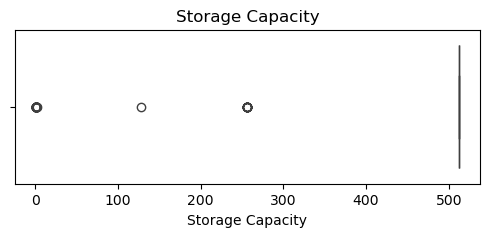

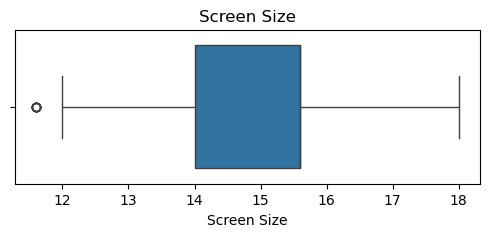

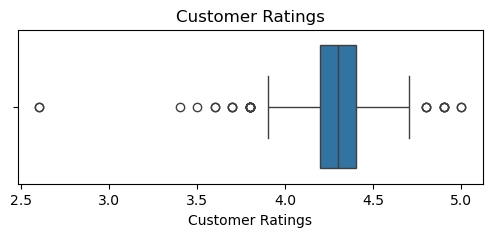

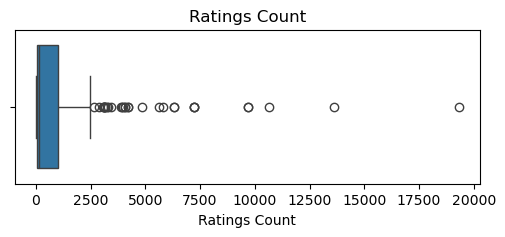

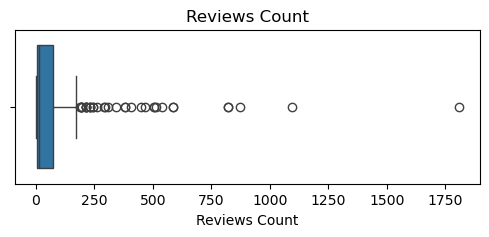

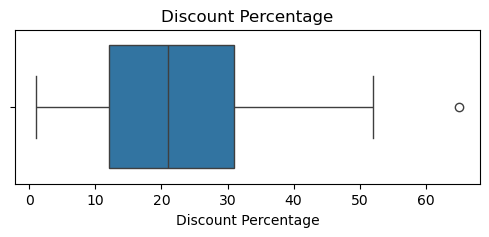

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = [
    'Prices',
    'RAM',
    'Storage Capacity',
    'Screen Size',
    'Customer Ratings',
    'Ratings Count',
    'Reviews Count',
    'Discount Percentage'
]

for col in numerical_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [106]:
# 2. Using IQR Method
Q1 = df['Prices'].quantile(0.25)
Q3 = df['Prices'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Prices'] < lower_bound) |
    (df['Prices'] > upper_bound)
]

print(outliers.shape)
outliers.head()

(15, 13)


,Prices,Brands,Model,Processor Type,RAM,Operating System,Storage Capacity,Storage Type,Screen Size,Customer Ratings,Ratings Count,Reviews Count,Discount Percentage
284,159980,ASUS,ASUS ROG Strix G16 (2025) with Office 2024 + M...,Intel Core i7 Processor,16,Windows 11 Home,1.0,SSD,16.0,4.9,61.0,10.0,35.0
292,152990,Apple,"Apple MacBook Air (M5, 2026) M5",Apple M5 Processor,24,Mac OS,1.0,SSD,13.6,4.7,552.0,56.0,4.0
295,149770,HP,HP HyperX Omen Intel Core i7 14th Gen 14650HX,Intel Core i7 Processor,24,Windows 11,1.0,SSD,15.3,4.4,57.0,6.0,6.0
308,199990,ASUS,ASUS Expertbook P5 Full metal AI PC with 1 Yr ...,Intel Core Ultra 7 Processor,32,Windows 11 Home,1.0,SSD,16.0,4.2,140.0,14.0,52.0
313,239990,ASUS,ASUS ExpertBook Ultra Copilot+ PC Intel Core U...,Intel Core Ultra X7 Processor,32,Windows 11 Home,1.0,SSD,14.0,4.9,11.0,2.0,46.0


#### Treatment of Outliers
For Laptop brand-wise and price analysis problem statement, expensive gaming laptops and premium laptops are real observations, not errors.

`Examples:`

- Apple MacBook Pro
- High-end gaming laptops
- Business workstations

Therefore, not removing price outliers.

High-priced laptops were retained because they represent genuine premium products available on Flipkart and are important for brand-wise and price analysis.

`Insight`:
Outliers were identified using boxplots and the IQR method. Numerical variables such as Price, RAM, Storage Capacity, Screen Size, Ratings Count, Reviews Count, and Discount Percentage were examined. Premium and gaming laptops with unusually high prices were retained because they represent valid market observations and are relevant to the business objective. No outliers were removed unless they were found to be data-entry errors.

####  Data Analysis and Visualization 
For Flipkart Laptop Price Analysis, the target feature is Prices. Performing EDA by analyzing how other features affect laptop prices.

1. Separate Numerical and Categorical Features

In [107]:
# Numerical Features
num_cols = [
    'Prices',
    'RAM',
    'Storage Capacity',
    'Screen Size',
    'Customer Ratings',
    'Ratings Count',
    'Reviews Count',
    'Discount Percentage'
]

cat_cols = [
    'Brands',
    'Processor Type',
    'Operating System',
    'Storage Type'
]

In [108]:
# Univariate Analysis
# Central Tendency
df[num_cols].describe()

,Prices,RAM,Storage Capacity,Screen Size,Customer Ratings,Ratings Count,Reviews Count,Discount Percentage
count,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000
mean,76034.357977,14.723735,406.093385,14.924125,4.256809,1028.015564,83.793774,22.031128
std,48154.006460,6.660690,197.616202,1.092357,0.295213,2208.028992,187.857057,13.438191
min,15299.000000,4.000000,1.000000,11.600000,2.600000,3.000000,0.000000,1.000000
25%,49800.000000,8.000000,512.000000,14.000000,4.200000,39.000000,3.000000,12.000000
50%,64990.000000,16.000000,512.000000,15.600000,4.300000,140.000000,14.000000,21.000000
75%,87612.000000,16.000000,512.000000,15.600000,4.400000,1029.000000,71.000000,31.000000
max,379990.000000,48.000000,512.000000,18.000000,5.000000,19316.000000,1808.000000,65.000000


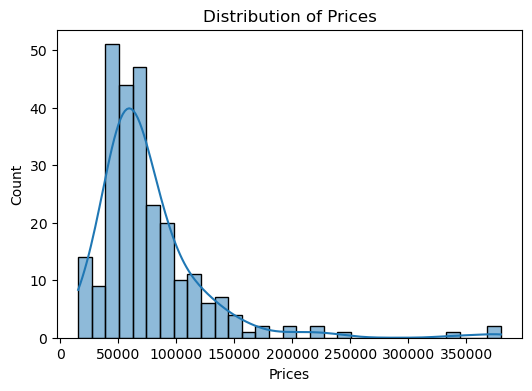

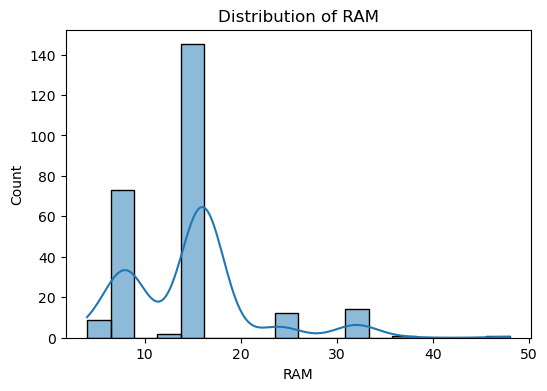

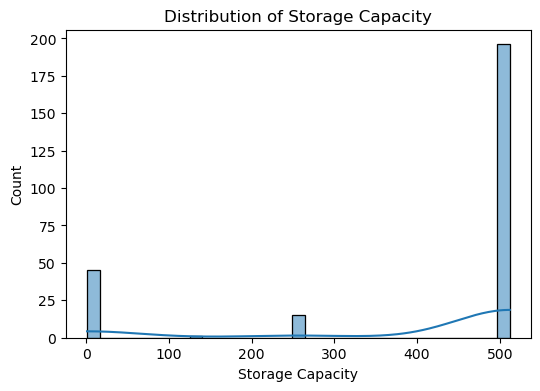

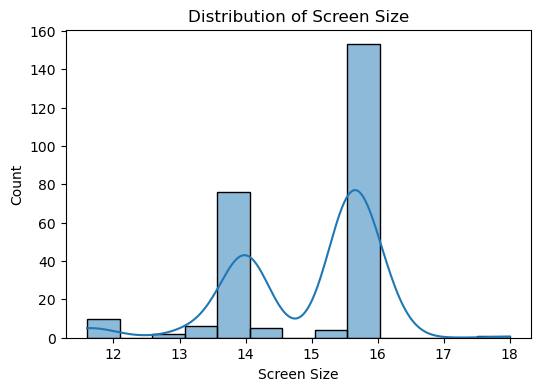

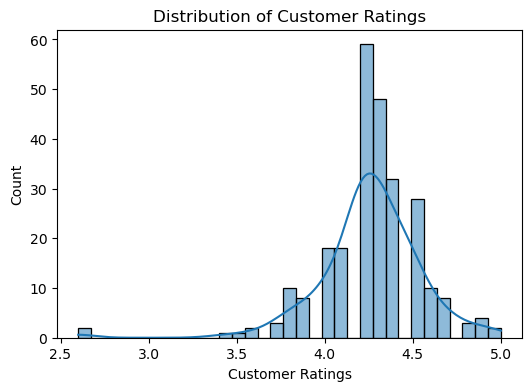

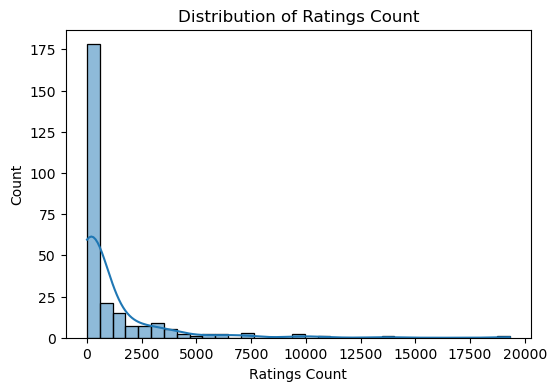

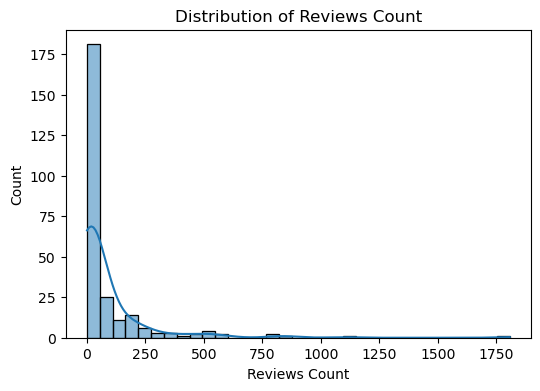

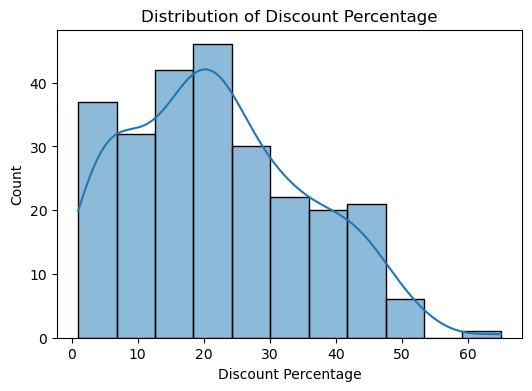

In [109]:
# Histogram
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

**Conclusions:**
- Most laptops are concentrated in the ₹30,000–₹60,000 range.
- RAM is dominated by 8 GB configurations.
- 512 GB is the most common storage capacity.
- Most customer ratings lie between 4.0 and 4.5.

#### Categorical Variable Analysis

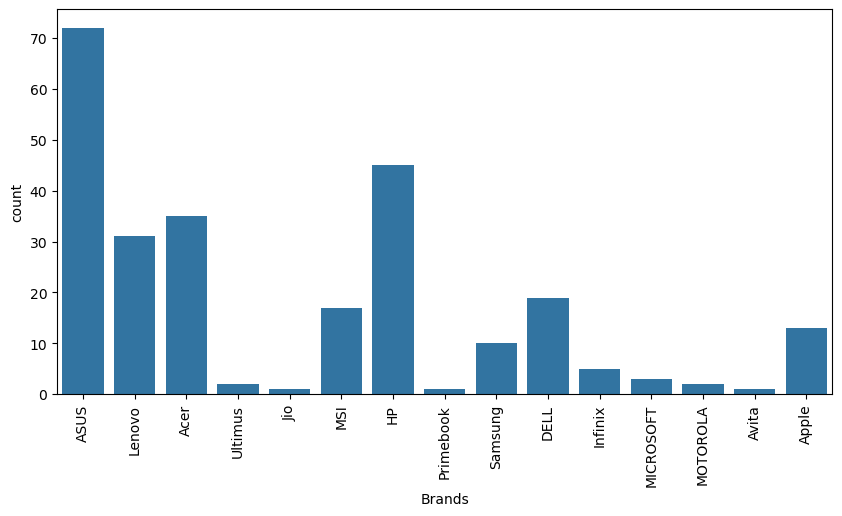

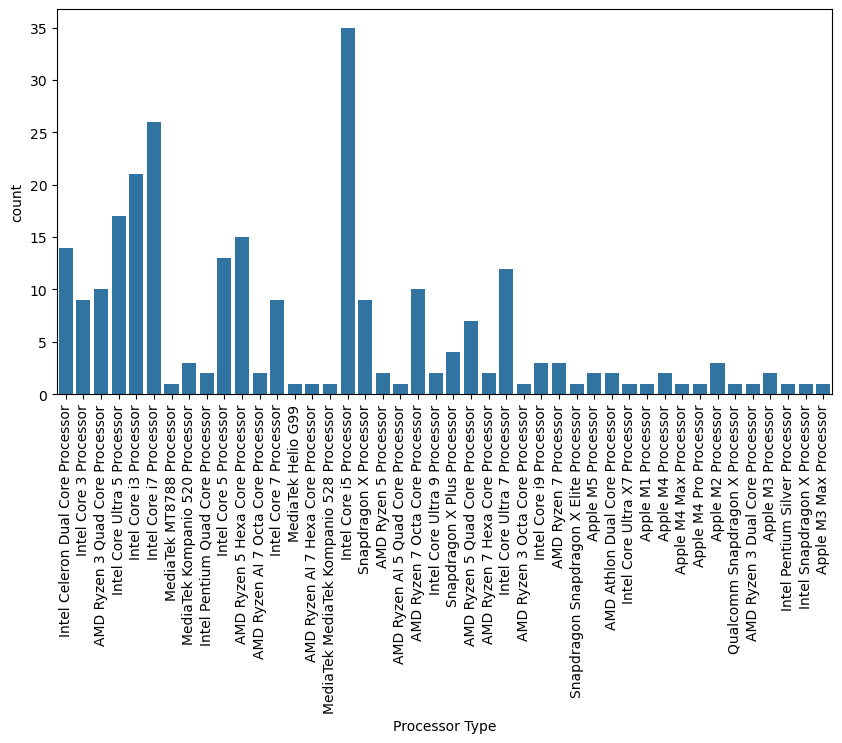

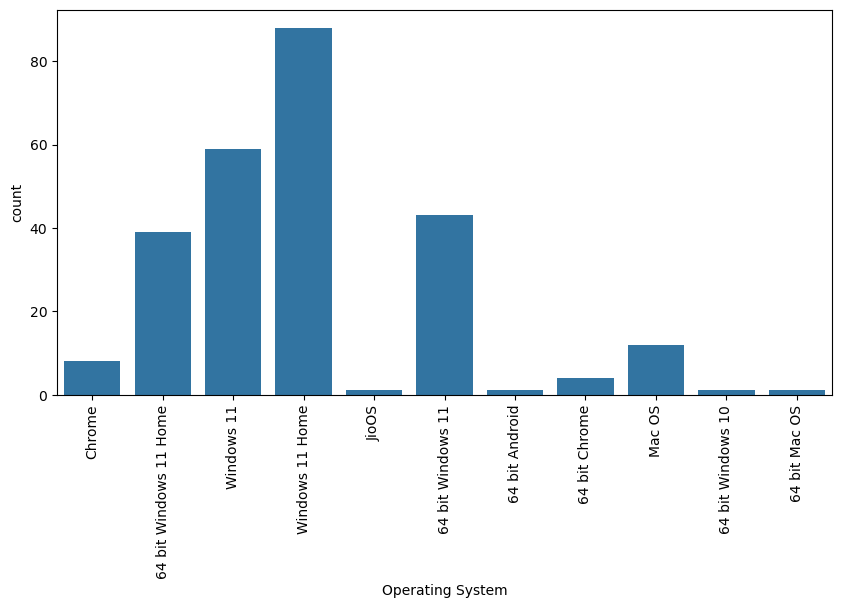

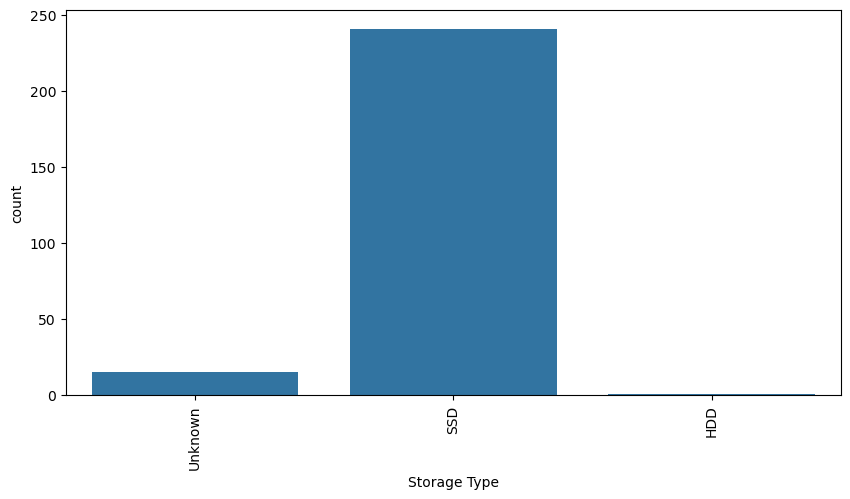

In [110]:
 for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=90)
    plt.show()

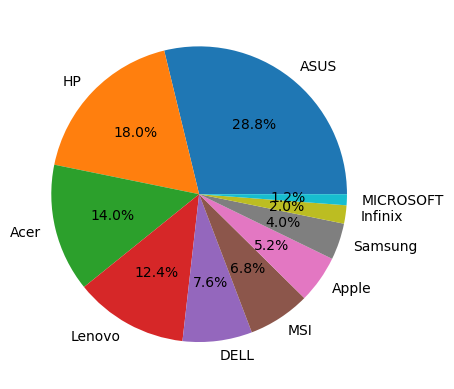

In [111]:
# Pie Chart
df['Brands'].value_counts().head(10).plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel('')
plt.show()

**Conclusions:**
1. ASUS, HP, and Lenovo have the highest number of listings.
2. Windows 11 is the dominant operating system.
3. SSD is the most common storage type.

#### Bivariate Analysis (Price vs Other Features)

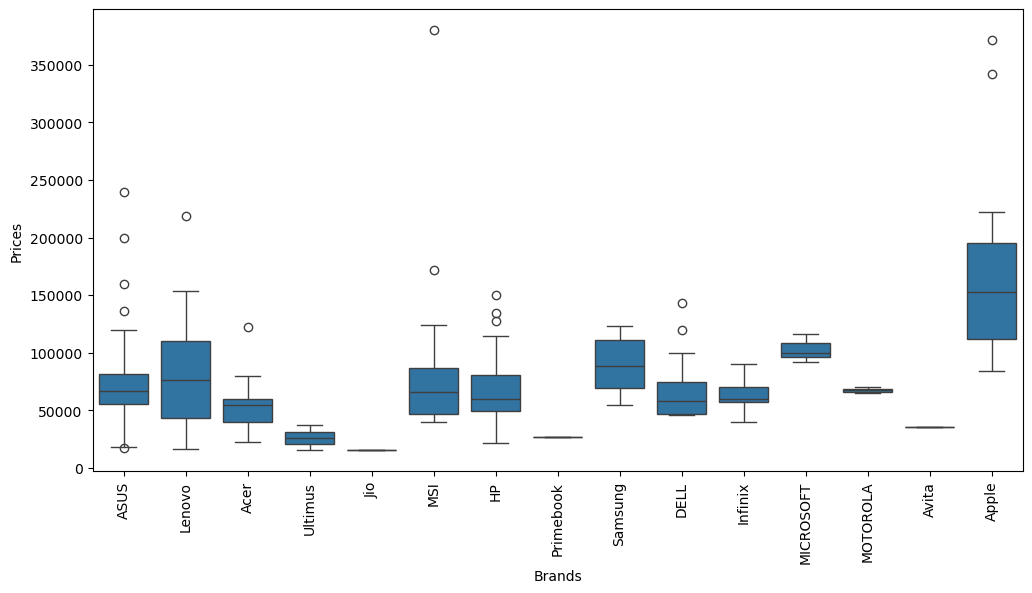

In [112]:
# Price vs Brand
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Brands', y='Prices')
plt.xticks(rotation=90)
plt.show()

**Conclusion:**
- Premium brands have higher median prices.
- Budget brands have lower price ranges.

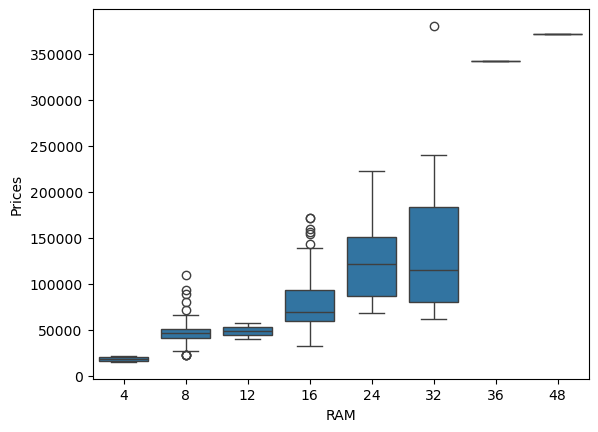

In [113]:
# Price vs RAM
sns.boxplot(data=df, x='RAM', y='Prices')
plt.show()

**Conclusion:**
- Laptop prices increase as RAM capacity increases.

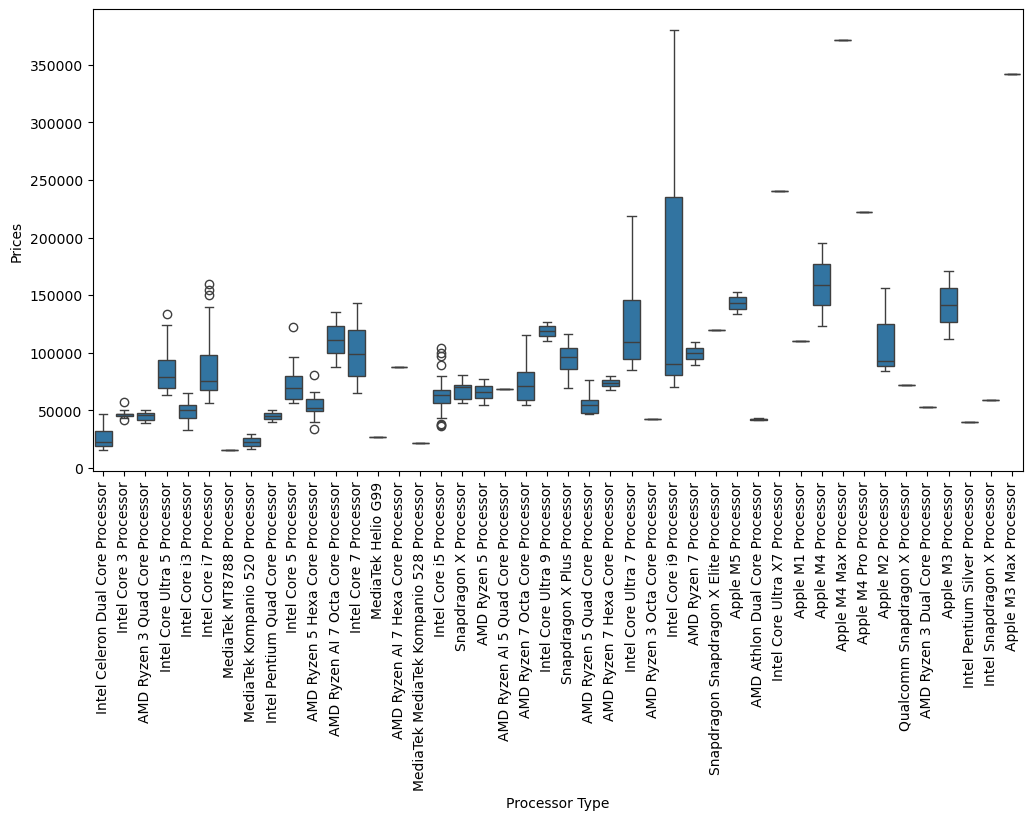

In [114]:
# Price vs Processor Type
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x='Processor Type',
    y='Prices'
)
plt.xticks(rotation=90)
plt.show()

**Conclusion**
- Higher-end processors are associated with higher laptop prices.

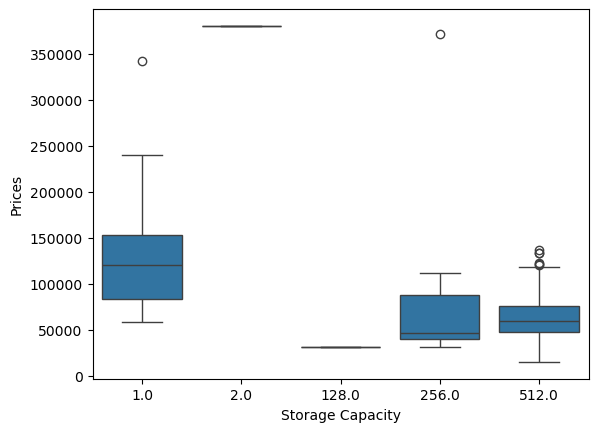

In [115]:
# Price vs Storage Capacity
sns.boxplot(
    data=df,
    x='Storage Capacity',
    y='Prices'
)
plt.show()

**Conclusion**
- Laptops with larger SSD capacities tend to be more expensive.

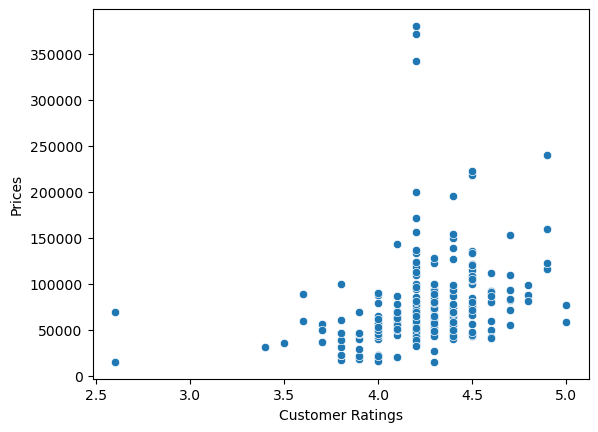

In [116]:
# Price vs Customer Ratings
sns.scatterplot(
    data=df,
    x='Customer Ratings',
    y='Prices'
)
plt.show()

**Conclusion**
- Customer ratings show only a weak relationship with price.

#### Correlation Analysis

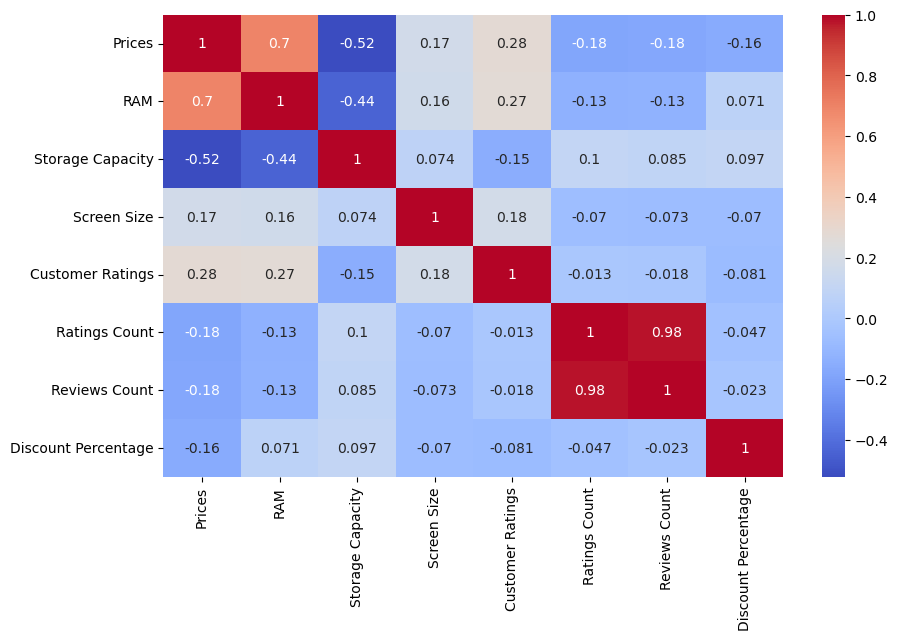

In [117]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()

**Conclusions**
- Price is positively correlated with RAM.
- Price is positively correlated with Storage Capacity.
- Ratings Count and Reviews Count are usually highly correlated.
- Discount Percentage may show a negative relationship with Price.

#### Business Insights for Final Report
1. Most laptops sold on Flipkart fall within the mid-range price segment.
2. 8 GB RAM and 512 GB SSD are the most common configurations.
3. Higher RAM and storage capacities significantly increase laptop prices.
4. Windows 11 dominates the laptop market.
5. SSD storage is preferred over HDD storage.
6. Premium brands generally command higher prices.
7. Customer ratings have limited impact on pricing.
8. Reviews Count and Ratings Count are strongly related, indicating that popular laptops attract more customer engagement.